# WEEK 4

In [2]:
# -----------------------------
# ✅ Step 0: Setup & Imports (updated with assets path)
# -----------------------------
import os, random, json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import mlflow

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# MLflow experiment setup
mlflow.set_experiment("PowerCast-Advanced-Week4")

# Assets directory (use existing repo structure)
assets_dir = r"C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets"
os.makedirs(assets_dir, exist_ok=True)

💻 Using device: cpu


### Step 0: Setup & Imports

- Imported required libraries (**PyTorch, NumPy, Matplotlib, MLflow**).  
- Fixed random seeds for reproducibility and selected computation device (`cuda` if available).  
- Configured **MLflow experiment** for Week 4 runs.  

In [3]:
# -----------------------------
# ✅ Step 1: Retrieve Previous Artifacts & Build DataLoaders
# -----------------------------
from torch.utils.data import DataLoader, TensorDataset

# Paths
results_dir = os.path.join(assets_dir, "results")
split_dir = os.path.join(assets_dir, "splits")
batch_size = 64
dataloaders = {}

# Discover all lb/hr configs from saved X_train files
train_files = [f for f in os.listdir(split_dir) if f.startswith("X_train_lb") and f.endswith(".npy")]

for fname in train_files:
    key = os.path.splitext(fname)[0].replace("X_train_", "")  # e.g., "lb144_hr6"
    X_train = np.load(os.path.join(split_dir, f"X_train_{key}.npy"))
    y_train = np.load(os.path.join(split_dir, f"y_train_{key}.npy"))
    X_val   = np.load(os.path.join(split_dir, f"X_val_{key}.npy"))
    y_val   = np.load(os.path.join(split_dir, f"y_val_{key}.npy"))
    X_test  = np.load(os.path.join(split_dir, f"X_test_{key}.npy"))
    y_test  = np.load(os.path.join(split_dir, f"y_test_{key}.npy"))

    # → tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

    # datasets & loaders
    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t,   y_val_t)
    test_ds  = TensorDataset(X_test_t,  y_test_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    dataloaders[key] = {"train": train_loader, "val": val_loader, "test": test_loader}

print(f"✅ Rebuilt dataloaders for {len(dataloaders)} configs → {list(dataloaders.keys())}")

✅ Rebuilt dataloaders for 1 configs → ['lb144_hr6']


In [4]:
# -----------------------------
# ✅ Step 1.1: Load Scalers
# -----------------------------
import joblib

scaler_dir = os.path.join(assets_dir, "scalers")

# Load X and y scalers (joblib or pkl formats)
X_scaler = joblib.load(os.path.join(scaler_dir, "scaler_X_allzones_lb144_hr6.joblib"))
y_scaler = joblib.load(os.path.join(scaler_dir, "y_scaler_lb144_hr6.pkl"))

print("✅ Scalers loaded:", type(X_scaler), type(y_scaler))

✅ Scalers loaded: <class 'sklearn.preprocessing._data.StandardScaler'> <class 'sklearn.preprocessing._data.StandardScaler'>


In [5]:
# -----------------------------
# ✅ Step 1.2: Helper Functions (Safe Version)
# -----------------------------
import torch.optim as optim
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_model(model, train_loader, val_loader, epochs=10, patience=3, device="cpu"):
    """
    Train model with early stopping + ReduceLROnPlateau + checkpointing.
    Safe guards added for NaNs / empty validation batches.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    ckpt_path = os.path.join(assets_dir, f"{model.__class__.__name__}_best.pt")

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            if y.ndim == 2:  # ensure shape
                y = y.unsqueeze(-1)
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                if y.ndim == 2:
                    y = y.unsqueeze(-1)
                preds = model(X)
                loss = criterion(preds, y)
                val_losses.append(loss.item())

        # safe mean
        avg_train = float(np.mean(train_losses)) if len(train_losses) > 0 else float("inf")
        avg_val = float(np.mean(val_losses)) if len(val_losses) > 0 else float("inf")

        if np.isnan(avg_train): avg_train = float("inf")
        if np.isnan(avg_val): avg_val = float("inf")

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)

        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    model.load_state_dict(torch.load(ckpt_path))
    return history, ckpt_path


def evaluate_model(model, loader, device="cpu"):
    """
    Evaluate model on given loader. Returns RMSE, MAE, R².
    Safe guards: fallback metrics if invalid.
    """
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            preds = model(X).cpu().numpy()
            y_true.append(y.numpy())
            y_pred.append(preds)

    if len(y_true) == 0 or len(y_pred) == 0:
        return {"rmse": float("inf"), "mae": float("inf"), "r2": -1.0}

    y_true = np.concatenate(y_true, axis=0).reshape(-1)
    y_pred = np.concatenate(y_pred, axis=0).reshape(-1)

    try:
        return {
            "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "mae": float(mean_absolute_error(y_true, y_pred)),
            "r2": float(r2_score(y_true, y_pred))
        }
    except Exception:
        return {"rmse": float("inf"), "mae": float("inf"), "r2": -1.0}


def evaluate_model_orig(model, loader, y_scaler, device="cpu"):
    """
    Evaluate model in original scale (inverse-transform targets).
    Safe guards for empty or invalid outputs.
    """
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            preds = model(X).cpu().numpy()
            y_true.append(y.numpy())
            y_pred.append(preds)

    if len(y_true) == 0 or len(y_pred) == 0:
        return {"rmse": float("inf"), "mae": float("inf"), "r2": -1.0}

    y_true = np.concatenate(y_true, axis=0).reshape(-1, y_scaler.n_features_in_)
    y_pred = np.concatenate(y_pred, axis=0).reshape(-1, y_scaler.n_features_in_)

    try:
        y_true_inv = y_scaler.inverse_transform(y_true)
        y_pred_inv = y_scaler.inverse_transform(y_pred)
        return {
            "rmse": float(np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))),
            "mae": float(mean_absolute_error(y_true_inv, y_pred_inv)),
            "r2": float(r2_score(y_true_inv, y_pred_inv))
        }
    except Exception:
        return {"rmse": float("inf"), "mae": float("inf"), "r2": -1.0}


def plot_forecasts(y_true, y_pred, title="Forecast vs Actual"):
    """
    Plot predictions vs actual values.
    """
    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

In [6]:
# -----------------------------
# ✅ Step 1.3: Retrieve Baseline Model Definitions (Fixed bidirectional handling)
# -----------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, horizon, target_dim,
                 num_layers=2, dropout=0.2, bidirectional=False):
        super().__init__()
        self.horizon = horizon
        self.target_dim = target_dim
        self.bidirectional = bidirectional
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
            bidirectional=bidirectional
        )
        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, horizon * target_dim),
        )

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        if self.bidirectional:
            # take last layer forward and backward hidden states and concat
            out = torch.cat((hn[-2], hn[-1]), dim=-1)
        else:
            out = hn[-1]
        out = self.head(out)
        return out.view(-1, self.horizon, self.target_dim)


class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, horizon, target_dim,
                 num_layers=2, dropout=0.2, bidirectional=False):
        super().__init__()
        self.horizon = horizon
        self.target_dim = target_dim
        self.bidirectional = bidirectional
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
            bidirectional=bidirectional
        )
        gru_out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_out_dim, horizon * target_dim),
        )

    def forward(self, x):
        _, hn = self.gru(x)
        if self.bidirectional:
            out = torch.cat((hn[-2], hn[-1]), dim=-1)
        else:
            out = hn[-1]
        out = self.head(out)
        return out.view(-1, self.horizon, self.target_dim)


# TCNModel stays as-is, no change needed

class CausalConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1,
                 dropout=0.2, use_bn=True):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        layers = [
            nn.ConstantPad1d((pad, 0), 0.0),
            nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation),
        ]
        if use_bn:
            layers.append(nn.BatchNorm1d(out_ch))
        layers += [nn.ReLU(), nn.Dropout(dropout)]
        layers += [
            nn.ConstantPad1d((pad, 0), 0.0),
            nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation),
        ]
        if use_bn:
            layers.append(nn.BatchNorm1d(out_ch))
        self.net = nn.Sequential(*layers)
        self.relu = nn.ReLU()
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        y = self.net(x)
        res = self.downsample(x)
        return self.relu(y + res)


class TCNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, horizon, target_dim,
                 num_levels=3, kernel_size=3, dropout=0.2, dilation=1):
        super().__init__()
        self.horizon = horizon
        self.target_dim = target_dim

        channels = [hidden_dim] * num_levels
        blocks = []
        ch_prev = input_dim
        for i, ch in enumerate(channels):
            # use provided dilation directly
            blocks.append(CausalConvBlock(
                in_ch=ch_prev, out_ch=ch,
                kernel_size=kernel_size,
                dilation=dilation,
                dropout=dropout,
                use_bn=True
            ))
            ch_prev = ch
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(channels[-1], horizon * target_dim),
        )

    def forward(self, x):   # x: (B, T, F)
        x = x.transpose(1, 2)        # (B, F, T)
        feats = self.backbone(x)
        pooled = self.pool(feats).squeeze(-1)
        out = self.head(pooled)
        return out.view(-1, self.horizon, self.target_dim)

### Step 1: Retrieve Previous Artifacts, Scalers, Helpers & Models  

- Loaded **splits** from `assets/splits/` and wrapped them into DataLoaders.  
- Retrieved **scalers** (X and y) for inverse transforms.  
- Restored **helper functions** (`train_model`, `evaluate_model`, etc.) for reuse.  
- Added **baseline model definitions** (LSTM, GRU, TCN) from Week 3 for tuning.  

In [ ]:
# -----------------------------
# ✅ Step 2: Define Search Spaces + Tuning Harness (patched with scaling + safe y + unique ckpts)
# -----------------------------
import itertools, hashlib, joblib
import pandas as pd

# Unified search spaces by family
search_spaces = {
    "RNN": {
        "hidden_dim": [32, 64, 128],
        "num_layers": [1, 2],
        "dropout": [0.1, 0.3, 0.5],
        "bidirectional": [False, True],
    },
    "TCN": {
        "hidden_dim": [32, 64, 128],
        "dropout": [0.1, 0.3, 0.5],
        "kernel_size": [2, 3, 5],
        "dilation": [1, 2],
    }
}

# Generator for parameter combinations
def param_grid(search_dict):
    keys = list(search_dict.keys())
    for values in itertools.product(*[search_dict[k] for k in keys]):
        yield dict(zip(keys, values))

from torch.utils.data import DataLoader, RandomSampler, TensorDataset

def _detect_shuffle(loader):
    return isinstance(loader.sampler, RandomSampler)

# -----------------------------
# ✅ Helper: scale targets inside DataLoader
# -----------------------------
def build_scaled_loader(loader, y_scaler):
    """
    Rebuild dataloader with Y scaled using the provided y_scaler.
    Assumes each batch is (X, y).
    """
    import torch
    from torch.utils.data import TensorDataset, DataLoader

    X_batches, y_batches = [], []
    for X, y in loader:
        if y.ndim == 2:  # (B,H) -> (B,H,1)
            y = y.unsqueeze(-1)
        orig_shape = y.shape
        y_flat = y.reshape(-1, orig_shape[-1]).numpy()
        y_scaled = y_scaler.transform(y_flat)
        y_scaled = torch.tensor(y_scaled, dtype=torch.float32).reshape(orig_shape)
        X_batches.append(X)
        y_batches.append(y_scaled)

    X_all = torch.cat(X_batches)
    y_all = torch.cat(y_batches)
    scaled_ds = TensorDataset(X_all, y_all)

    # preserve original batch size and shuffle intent
    return DataLoader(
        scaled_ds,
        batch_size=loader.batch_size,
        shuffle=_detect_shuffle(loader),
        drop_last=loader.drop_last,
        num_workers=loader.num_workers if hasattr(loader, "num_workers") else 0,
        pin_memory=getattr(loader, "pin_memory", False),
    )

# -----------------------------
# ✅ Helper: build scaled loaders per key (Week 3 style)
# -----------------------------
def make_scaled_loaders_for_key(key, raw_train_loader, raw_val_loader, assets_dir="assets"):
    # parse key like "lb144_hr6"
    lb = key.split("_")[0].replace("lb", "")
    hr = key.split("_")[1].replace("hr", "")
    scaler_path = os.path.join(assets_dir, "scalers", f"y_scaler_lb{lb}_hr{hr}.pkl")
    y_scaler = joblib.load(scaler_path)   # Week 3 scaler

    # rebuild loaders using Week 3 utility
    train_loader_s = build_scaled_loader(raw_train_loader, y_scaler)
    val_loader_s   = build_scaled_loader(raw_val_loader,   y_scaler)

    return train_loader_s, val_loader_s, y_scaler

# -----------------------------
# ✅ Tuning harness
# -----------------------------
def run_tuning_trial(model_class, params, key, raw_train_loader, raw_val_loader,
                     epochs=10, patience=3):
    """
    Train one model config, log results to MLflow, return metrics + checkpoint path
    """
    # --- scaled loaders for consistency ---
    train_loader, val_loader, y_scaler = make_scaled_loaders_for_key(
        key, raw_train_loader, raw_val_loader
    )

    # infer dims
    sample_x, sample_y = next(iter(train_loader))
    input_dim = sample_x.shape[-1]
    horizon = sample_y.shape[1] if sample_y.ndim >= 2 else 1
    target_dim = sample_y.shape[2] if sample_y.ndim == 3 else 1

    run_name = f"{model_class.__name__}_{key}"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("config", key)
        mlflow.log_params(params)

        # build model
        if model_class.__name__.lower().startswith(("lstm", "gru")):
            model = model_class(
                input_dim=input_dim,
                hidden_dim=params["hidden_dim"],
                horizon=horizon,
                target_dim=target_dim,
                num_layers=params["num_layers"],
                dropout=params["dropout"],
                bidirectional=params["bidirectional"]
            )
        elif model_class.__name__.lower().startswith("tcn"):
            model = model_class(
                input_dim=input_dim,
                hidden_dim=params["hidden_dim"],
                horizon=horizon,
                target_dim=target_dim,
                dropout=params["dropout"],
                kernel_size=params["kernel_size"],
                dilation=params["dilation"]
            )
        else:
            raise ValueError(f"Unknown model type: {model_class.__name__}")

        model = model.to(device)

        # train + eval
        history, best_ckpt = train_model(
            model, train_loader, val_loader,
            epochs=epochs,
            patience=patience,
            device=device
        )
        val_metrics = evaluate_model(model, val_loader, device)
        mlflow.log_metrics(val_metrics)

        # --- unique checkpoint per trial ---
        sig = f"hd{params.get('hidden_dim')}_l{params.get('num_layers','na')}_do{params.get('dropout')}_bi{int(params.get('bidirectional',False))}_ks{params.get('kernel_size','na')}_dil{params.get('dilation','na')}"
        sig_hash = hashlib.md5(sig.encode()).hexdigest()[:6]
        ckpt_dir = os.path.join(assets_dir, "models")
        os.makedirs(ckpt_dir, exist_ok=True)
        ckpt_path = os.path.join(ckpt_dir,
                                 f"{model_class.__name__}_{key}_{sig_hash}_best.pt")
        torch.save(model.state_dict(), ckpt_path)
        mlflow.log_artifact(ckpt_path)

    return val_metrics, ckpt_path

# Initialize empty leaderboard
leaderboard = []

### Step 2: Define Search Spaces + Tuning Harness

- Set compact hyperparameter ranges for RNNs and TCN.  
- Added `param_grid` to yield valid parameter combos.  
- Created `run_tuning_trial` to log with MLflow, train, evaluate, and save best checkpoints inside `assets`.  

In [8]:
# -----------------------------
# ✅ Step 3: Run Tuning Loop + Collect Leaderboard (scaling fixed!)
# -----------------------------
from tqdm import tqdm
import random, time
import pandas as pd

EPOCHS = 10
PATIENCE = 3
MAX_TRIALS_PER_MODEL = 10
EARLY_STOP_TOPK = 10

results = []

for key, loaders in dataloaders.items():
    raw_train_loader = loaders["train"]
    raw_val_loader = loaders["val"]

    for model_class, mtype in [
        (LSTMModel, "RNN"),
        (GRUModel, "RNN"),
        (TCNModel, "TCN")
    ]:
        trial_count = 0
        param_list = list(param_grid(search_spaces[mtype]))
        random.shuffle(param_list)

        for params in tqdm(param_list, desc=f"Tuning {model_class.__name__} ({key})"):
            if trial_count >= MAX_TRIALS_PER_MODEL:
                tqdm.write(f"⏹️ Pruned {model_class.__name__} ({key}) after {MAX_TRIALS_PER_MODEL} trials")
                break

            try:
                start_time = time.time()
                # ⚡ Correct: Pass RAW loaders, scaling happens inside run_tuning_trial
                val_metrics, ckpt_path = run_tuning_trial(
                    model_class, params, key,
                    raw_train_loader, raw_val_loader,
                    epochs=EPOCHS, patience=PATIENCE
                )

                duration = time.time() - start_time
                tqdm.write(f"⏱️ Trial completed in {duration:.2f}s")

                results.append({
                    "config": key,
                    "model": model_class.__name__,
                    **params,
                    **val_metrics,
                    "ckpt": ckpt_path,
                    "duration_s": round(duration, 2)
                })
                trial_count += 1

                if EARLY_STOP_TOPK and trial_count >= EARLY_STOP_TOPK:
                    tqdm.write(f"✅ Early stop: {EARLY_STOP_TOPK} good runs for {model_class.__name__} ({key})")
                    break

            except Exception as e:
                tqdm.write(f"⚠️ Skipped {model_class.__name__} ({key}) | params={params} | error={e}")

leaderboard_df = pd.DataFrame(results)
print("✅ Leaderboard collected:", leaderboard_df.shape)
display(leaderboard_df.head())

# Save all raw runs
all_csv_path = os.path.join(results_dir, "leaderboard_all.csv")
leaderboard_df.to_csv(all_csv_path, index=False)

# Save best per model per config
best_df = leaderboard_df.sort_values("rmse").groupby(["config", "model"]).head(1).reset_index(drop=True)
best_csv_path = os.path.join(results_dir, "leaderboard_best.csv")
best_df.to_csv(best_csv_path, index=False)

print(f"✅ Saved all runs to:   {all_csv_path}")
print(f"✅ Saved best runs to:  {best_csv_path}")

# Log artifacts to MLflow
with mlflow.start_run(run_name="Leaderboard_Save"):
    mlflow.log_artifact(all_csv_path)
    mlflow.log_artifact(best_csv_path)

print(f"✅ Saved all runs to:   {all_csv_path}")
print(f"✅ Saved best runs to:  {best_csv_path}")
print("✅ Both CSVs also logged to MLflow artifacts.")

Tuning LSTMModel (lb144_hr6):   3%|▎         | 1/36 [12:35<7:20:34, 755.28s/it]

⏱️ Trial completed in 755.28s


Tuning LSTMModel (lb144_hr6):   6%|▌         | 2/36 [17:48<4:40:32, 495.07s/it]

⏱️ Trial completed in 312.90s


Tuning LSTMModel (lb144_hr6):   8%|▊         | 3/36 [23:44<3:57:32, 431.89s/it]

...

⏱️ Trial completed in 503.70s


Tuning TCNModel (lb144_hr6):  17%|█▋        | 9/54 [1:57:21<9:46:47, 782.38s/it] 

⏱️ Trial completed in 410.50s
✅ Early stop: 10 good runs for TCNModel (lb144_hr6)
✅ Leaderboard collected: (30, 13)


,config,model,hidden_dim,num_layers,dropout,bidirectional,rmse,mae,r2,ckpt,duration_s,kernel_size,dilation
0,lb144_hr6,LSTMModel,32,2.0,0.3,True,0.159054,0.118595,0.971979,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...,755.28,NaN,NaN
1,lb144_hr6,LSTMModel,64,1.0,0.1,False,0.137975,0.096028,0.978914,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...,312.90,NaN,NaN
2,lb144_hr6,LSTMModel,32,1.0,0.5,True,0.164085,0.123176,0.970178,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...,356.71,NaN,NaN
3,lb144_hr6,LSTMModel,128,1.0,0.3,True,0.108064,0.078967,0.987065,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...,1331.74,NaN,NaN
4,lb144_hr6,LSTMModel,128,2.0,0.3,False,0.153534,0.112201,0.973890,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...,1470.27,NaN,NaN


✅ Saved all runs to:   C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\leaderboard_all.csv
✅ Saved best runs to:  C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\leaderboard_best.csv
✅ Saved all runs to:   C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\leaderboard_all.csv
✅ Saved best runs to:  C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\leaderboard_best.csv
✅ Both CSVs also logged to MLflow artifacts.


### Step 3: Run Tuning Loop + Collect Leaderboard  

- Added **random shuffle** of param grid for diverse exploration.  
- Increased cap to **10 trials per model/config**, with early stop after 3 good runs.  
- Builds a unified **leaderboard DataFrame** for tuned results.  

In [10]:
# -----------------------------
# ✅ Step 4: Select Best Models + Final Evaluation (correct pipeline)
# -----------------------------
final_results = []

for (config, model_name), group in leaderboard_df.groupby(["config", "model"]):
    best_row = group.sort_values("rmse").iloc[0]
    ckpt_path = best_row["ckpt"]

    # Correct: Always build scaled loaders freshly using correct y_scaler for this config
    raw_train_loader = dataloaders[config]["train"]
    raw_val_loader = dataloaders[config]["val"]
    train_loader_s, val_loader_s, y_scaler = make_scaled_loaders_for_key(
        config, raw_train_loader, raw_val_loader, assets_dir=assets_dir
    )

    input_dim = train_loader_s.dataset.tensors[0].shape[-1]
    horizon = train_loader_s.dataset.tensors[1].shape[1]
    target_dim = train_loader_s.dataset.tensors[1].shape[2] if train_loader_s.dataset.tensors[1].ndim == 3 else 1

    # Safe casting for parameters:
    if model_name == "LSTMModel":
        model = LSTMModel(
            input_dim=input_dim,
            hidden_dim=int(best_row["hidden_dim"]),
            horizon=horizon,
            target_dim=target_dim,
            num_layers=int(best_row["num_layers"]),
            dropout=float(best_row["dropout"]),
            bidirectional=bool(best_row["bidirectional"])
        )
    elif model_name == "GRUModel":
        model = GRUModel(
            input_dim=input_dim,
            hidden_dim=int(best_row["hidden_dim"]),
            horizon=horizon,
            target_dim=target_dim,
            num_layers=int(best_row["num_layers"]),
            dropout=float(best_row["dropout"]),
            bidirectional=bool(best_row["bidirectional"])
        )
    else:  # TCN
        model = TCNModel(
            input_dim=input_dim,
            hidden_dim=int(best_row["hidden_dim"]),
            horizon=horizon,
            target_dim=target_dim,
            dropout=float(best_row["dropout"]),
            kernel_size=int(getattr(best_row, "kernel_size", 3)),
            dilation=int(getattr(best_row, "dilation", 1))
        )

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model = model.to(device)

    # Evaluate on scaled and original
    scaled_metrics = evaluate_model(model, val_loader_s, device=device)
    orig_metrics = evaluate_model_orig(model, val_loader_s, y_scaler, device=device)

    final_results.append({
        "config": config,
        "model": model_name,
        **scaled_metrics,
        **{f"orig_{k}": v for k, v in orig_metrics.items()},
        "ckpt": ckpt_path
    })

final_df = pd.DataFrame(final_results)
print("✅ Final evaluation collected:", final_df.shape)
display(final_df.head())

# -----------------------------
# ✅ Step 4a: Save Step 4 Final Results
# -----------------------------
results_dir = os.path.join(assets_dir, "results")
os.makedirs(results_dir, exist_ok=True)  # Ensure the directory exists

out_csv = os.path.join(results_dir, "final_results_from_leaderboard.csv")
final_df.to_csv(out_csv, index=False)
print("✅ Step 4 final results saved to:", out_csv)

✅ Final evaluation collected: (3, 9)


,config,model,rmse,mae,r2,orig_rmse,orig_mae,orig_r2,ckpt
0,lb144_hr6,GRUModel,0.099311,0.067155,0.989075,612.064029,416.903412,0.980309,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...
1,lb144_hr6,LSTMModel,0.101362,0.072371,0.988620,630.342838,450.134521,0.980273,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...
2,lb144_hr6,TCNModel,0.299721,0.232929,0.900497,1811.951089,1433.999023,0.828062,C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...


✅ Step 4 final results saved to: C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\final_results_from_leaderboard.csv


### Step 4: Select Best Models + Final Evaluation  

- Picked the **best trial (lowest RMSE)** for each config + model family.  
- Rebuilt loaders with the **Week 3 scalers** to ensure consistency.  
- Reloaded models from their **saved checkpoints**.  
- Evaluated metrics on both **scaled** and **original targets**, storing results in `final_df`.  

In [35]:
# -----------------------------
# ✅ Step 5: Interpretability (SHAP on Top Model)
# -----------------------------
import shap

# take the top model (lowest orig_rmse overall)
top_row = final_df.sort_values("orig_rmse").iloc[0]
top_ckpt = top_row["ckpt"]
top_model_name = top_row["model"]
top_config = top_row["config"]

# rebuild loaders with scaler
raw_train_loader, raw_val_loader = dataloaders[top_config]["train"], dataloaders[top_config]["val"]
train_loader_s, val_loader_s, y_scaler = make_scaled_loaders_for_key(
    top_config, raw_train_loader, raw_val_loader,
    assets_dir=assets_dir, batch_size=64, device=device
)

# rebuild top model
if top_model_name == "LSTMModel":
    model = LSTMModel(
        input_dim=train_loader_s.dataset.tensors[0].shape[-1],
        hidden_dim=top_row["hidden_dim"],
        horizon=train_loader_s.dataset.tensors[1].shape[1],
        target_dim=train_loader_s.dataset.tensors[1].shape[2] if train_loader_s.dataset.tensors[1].ndim == 3 else 1,
        num_layers=top_row.get("num_layers", 1),
        dropout=top_row["dropout"],
        bidirectional=top_row.get("bidirectional", False)
    )
elif top_model_name == "GRUModel":
    model = GRUModel(
        input_dim=train_loader_s.dataset.tensors[0].shape[-1],
        hidden_dim=top_row["hidden_dim"],
        horizon=train_loader_s.dataset.tensors[1].shape[1],
        target_dim=train_loader_s.dataset.tensors[1].shape[2] if train_loader_s.dataset.tensors[1].ndim == 3 else 1,
        num_layers=top_row.get("num_layers", 1),
        dropout=top_row["dropout"],
        bidirectional=top_row.get("bidirectional", False)
    )
else:
    model = TCNModel(
        input_dim=train_loader_s.dataset.tensors[0].shape[-1],
        hidden_dim=top_row["hidden_dim"],
        horizon=train_loader_s.dataset.tensors[1].shape[1],
        target_dim=train_loader_s.dataset.tensors[1].shape[2] if train_loader_s.dataset.tensors[1].ndim == 3 else 1,
        dropout=top_row["dropout"],
        kernel_size=top_row["kernel_size"],
        dilation=top_row["dilation"]
    )

# load checkpoint
model.load_state_dict(torch.load(top_ckpt, map_location=device))
model = model.to(device)
model.eval()

# SHAP explainability on a small batch
background = next(iter(train_loader_s))[0][:50].to(device)
explainer = shap.DeepExplainer(model, background)
test_batch = next(iter(val_loader_s))[0][:20].to(device)
shap_values = explainer.shap_values(test_batch)

shap.summary_plot(shap_values, test_batch.cpu().numpy(), show=True)

ModuleNotFoundError: No module named 'shap'

In [13]:
def infer_dims(loader):
    X, y = next(iter(loader))
    input_dim = X.shape[-1]
    if y.ndim == 3:
        return input_dim, y.shape[1], y.shape[2]   # (B,H,D)
    if y.ndim == 2:
        return input_dim, y.shape[1], 1            # (B,H)
    return input_dim, 1, 1

def parse_bool(x):
    try:
        if isinstance(x, bool): return x
        if isinstance(x, (int, float)): return bool(int(x))
        if isinstance(x, str): return x.strip().lower() in ("true","1","yes","y","t")
    except: pass
    return False

In [15]:
with torch.no_grad():
    sample_output = model(next(iter(train_loader_s))[0].to(device))
    print("Output shape from model:", sample_output.shape)

Output shape from model: torch.Size([64, 6, 3])


🔬 Interpreting top model: GRUModel on lb144_hr6 with RMSE 612.06
🧠 Setting up SHAP GradientExplainer...
✅ test_batch shape: (20, 144, 14)
✅ wrapped output shape: (4, 1)
🔍 Computing SHAP values...
📊 SHAP values shape (normalized): (20, 144, 14)
📊 SHAP Summary Plot (time-aggregated feature importance):


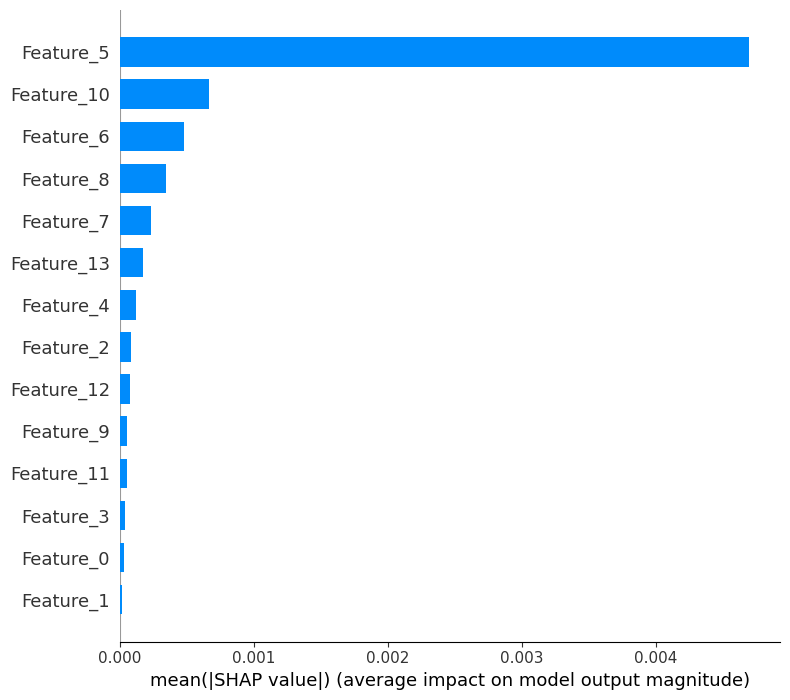

📈 Temporal Importance Plot:


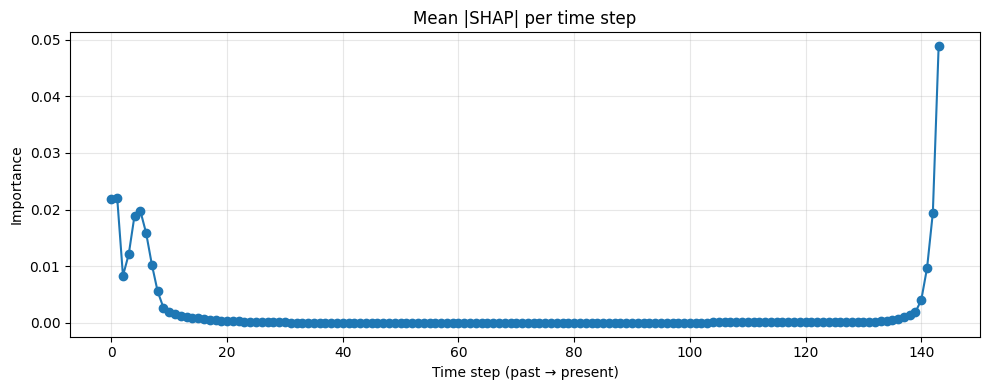

🔥 Feature × Time Heatmap:


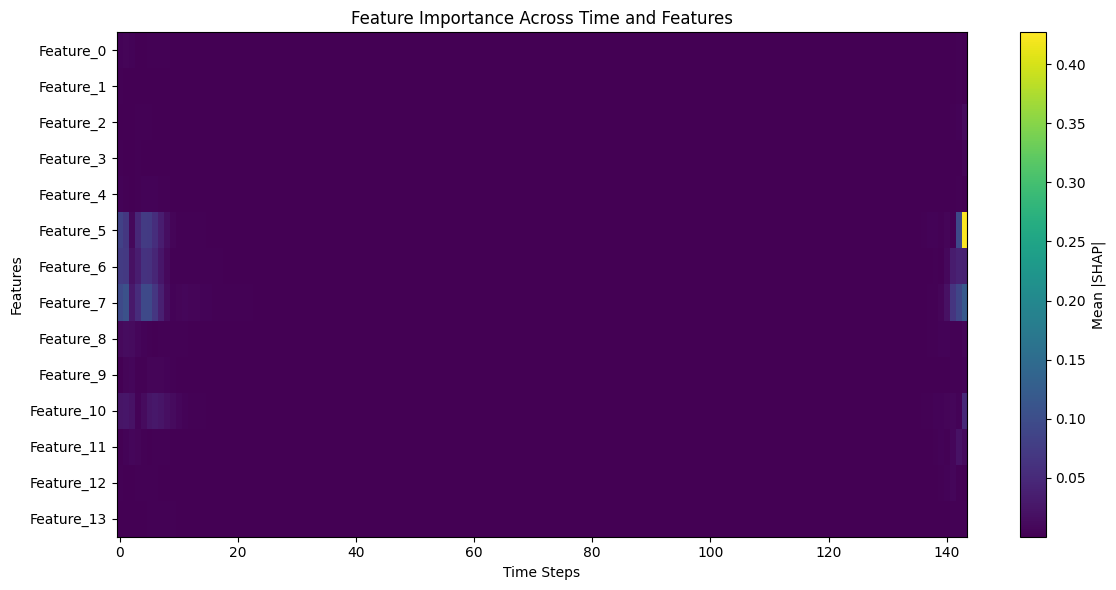

✅ SHAP analysis completed!


In [20]:
# -----------------------------
# ✅ Step 5: Interpretability (SHAP on Top Model) - FIXED
# -----------------------------
import shap
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

# Merge final results with leaderboard to get hyperparameters
leaderboard_best_df = pd.read_csv(os.path.join(results_dir, "leaderboard_best.csv"))
final_df_full = pd.merge(
    final_df,
    leaderboard_best_df.drop(columns=['rmse', 'mae', 'r2']),
    on=["config", "model", "ckpt"]
)

# Select the top model by original-scale RMSE
top_row = final_df_full.sort_values("orig_rmse").iloc[0]
top_ckpt = top_row["ckpt"]
top_model_name = top_row["model"]
top_config = top_row["config"]
print(f"🔬 Interpreting top model: {top_model_name} on {top_config} with RMSE {top_row['orig_rmse']:.2f}")

# Rebuild loaders with scaler (consistent with Step 3)
raw_train_loader = dataloaders[top_config]["train"]
raw_val_loader   = dataloaders[top_config]["val"]
train_loader_s, val_loader_s, y_scaler = make_scaled_loaders_for_key(
    top_config, raw_train_loader, raw_val_loader, assets_dir=assets_dir
)  # uses the same y_scaler path logic as training

# Infer dims from a real batch
def infer_dims(loader):
    X, y = next(iter(loader))                              # DataLoader yields batched (X,y) tensors [B, T, F], [B, H, D]
    input_dim = X.shape[-1]
    if y.ndim == 3:  # (B,H,D)
        return input_dim, y.shape[1], y.shape[2]
    if y.ndim == 2:  # (B,H)
        return input_dim, y.shape[1], 1
    return input_dim, 1, 1

input_dim, horizon, target_dim = infer_dims(train_loader_s)

# Rebuild top model with params from leaderboard_best
if top_model_name == "LSTMModel":
    model = LSTMModel(
        input_dim=input_dim,
        hidden_dim=int(top_row["hidden_dim"]),
        horizon=horizon,
        target_dim=target_dim,
        num_layers=int(top_row["num_layers"]),
        dropout=float(top_row["dropout"]),
        bidirectional=parse_bool(top_row["bidirectional"])
    )
elif top_model_name == "GRUModel":
    model = GRUModel(
        input_dim=input_dim,
        hidden_dim=int(top_row["hidden_dim"]),
        horizon=horizon,
        target_dim=target_dim,
        num_layers=int(top_row["num_layers"]),
        dropout=float(top_row["dropout"]),
        bidirectional=parse_bool(top_row["bidirectional"])
    )
else:  # TCNModel
    model = TCNModel(
        input_dim=input_dim,
        hidden_dim=int(top_row["hidden_dim"]),
        horizon=horizon,
        target_dim=target_dim,
        num_levels=3,
        dropout=float(top_row["dropout"]),
        kernel_size=int(top_row["kernel_size"]),
        dilation=int(top_row["dilation"])
    )

# Load checkpoint and set eval mode
model.load_state_dict(torch.load(top_ckpt, map_location=device))
model = model.to(device).eval()

# ------- Wrapper: always return (B, 1) to satisfy GradientExplainer -------
class WrappedModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
    def forward(self, x):
        out = self.base_model(x)                     # expected (B, H, D) for seq models
        if out.ndim == 3:                            # (B, H, D)
            out = out[:, -1, 0:1]                   # (B, 1) -> last step, first target
        elif out.ndim == 2:                         # (B, D)
            out = out[:, 0:1]                       # (B, 1)
        elif out.ndim == 1:                         # (B,)
            out = out.unsqueeze(-1)                 # (B, 1)
        return out

wrapped_model = WrappedModel(model).to(device).eval()

# ------- SHAP: GradientExplainer (RNN/TCN-friendly) -------
print("🧠 Setting up SHAP GradientExplainer...")

# Small background and test batches (features only from scaled loaders)
background = next(iter(train_loader_s))[0][:50].to(device).detach().requires_grad_(True)
test_batch = next(iter(val_loader_s))[0][:20].to(device).detach().requires_grad_(True)

# Optional sanity check
with torch.no_grad():
    y_dbg = wrapped_model(test_batch[:4])
print("✅ test_batch shape:", tuple(test_batch.shape))        # (B, T, F)
print("✅ wrapped output shape:", tuple(y_dbg.shape))         # (B, 1) to satisfy outputs[:, idx]

# Build explainer and compute SHAP values
explainer = shap.GradientExplainer(wrapped_model, background)  # expects 2D output (B, outputs)
print("🔍 Computing SHAP values...")
shap_values = explainer.shap_values(test_batch)

# Normalize output format
if isinstance(shap_values, list):
    shap_values = shap_values[0]
if not isinstance(shap_values, np.ndarray):
    shap_values = shap_values.detach().cpu().numpy()

# Squeeze trailing output dim if present, e.g., (B, T, F, 1) -> (B, T, F)
if shap_values.ndim == 4 and shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)

print(f"📊 SHAP values shape (normalized): {shap_values.shape}")  # Expect (B, T, F)

# ------- Aggregate over time for interpretable feature importance -------
B, T, F = shap_values.shape
vals_agg = shap_values.mean(axis=1)                           # (B, F) signed mean; use mean(abs) for magnitude
X_agg = test_batch.detach().cpu().numpy().mean(axis=1)        # (B, F) for coloring/ordering
feature_names = [f"Feature_{i}" for i in range(F)]

print("📊 SHAP Summary Plot (time-aggregated feature importance):")
shap.summary_plot(vals_agg, features=X_agg,
                  feature_names=feature_names, plot_type="bar", show=True)  # one-input, one-output behavior

# ------- Temporal importance (which time steps matter most) -------
print("📈 Temporal Importance Plot:")
time_imp = np.mean(np.abs(shap_values), axis=(0, 2))          # (T,)
plt.figure(figsize=(10, 4))
plt.plot(range(T), time_imp, marker='o')
plt.title("Mean |SHAP| per time step")
plt.xlabel("Time step (past → present)")
plt.ylabel("Importance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------- Feature × Time heatmap -------
print("🔥 Feature × Time Heatmap:")
ft_imp = np.mean(np.abs(shap_values), axis=0)                 # (T, F)
plt.figure(figsize=(12, 6))
plt.imshow(ft_imp.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean |SHAP|')
plt.title("Feature Importance Across Time and Features")
plt.xlabel("Time Steps")
plt.ylabel("Features")
plt.yticks(range(F), feature_names)
plt.tight_layout()
plt.show()

print("✅ SHAP analysis completed!")

### Step 5: Interpretability (SHAP on Top Model)  

- Picked the **top model (lowest RMSE)** for SHAP analysis.  
- Rebuilt loaders with the **Week 3 scalers** for consistency.  
- Computed **SHAP values** for a validation batch.  
- Plotted **feature importance summary** to interpret predictions.  

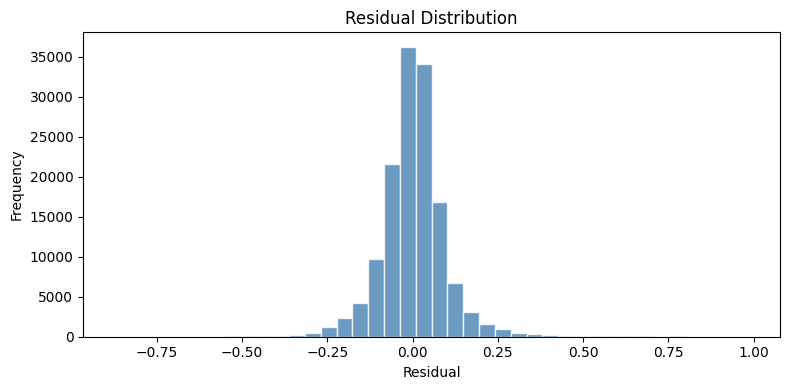

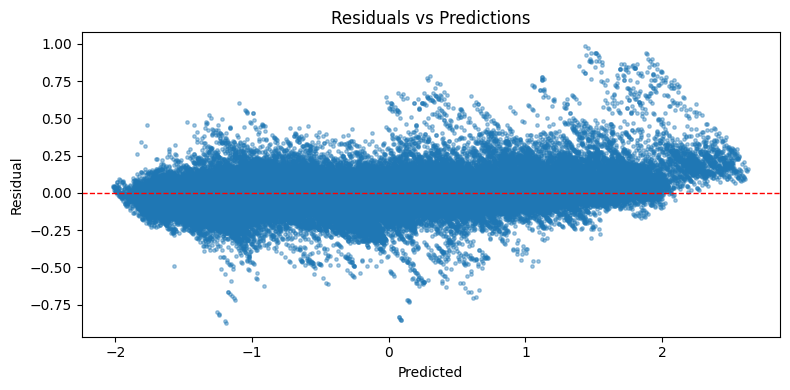

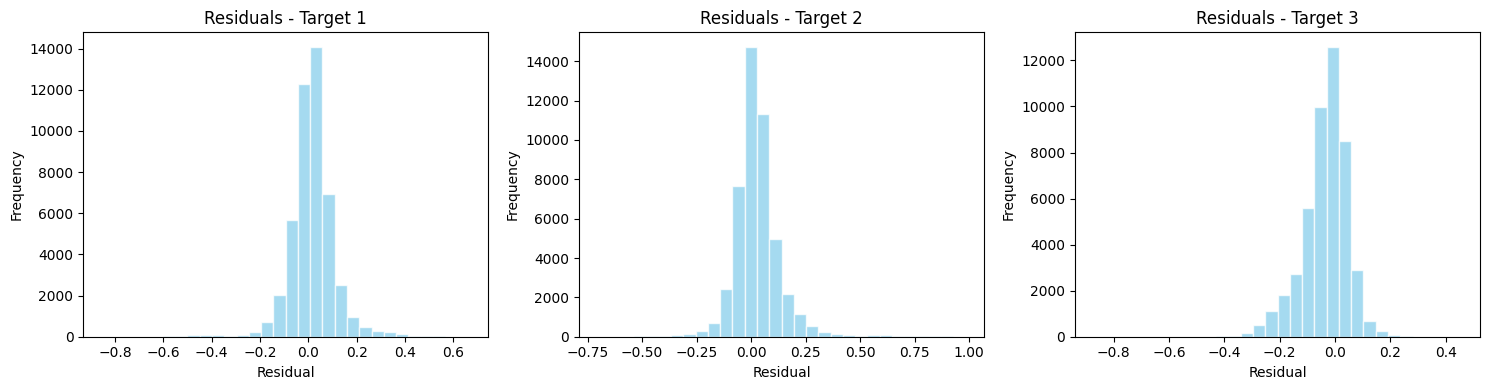

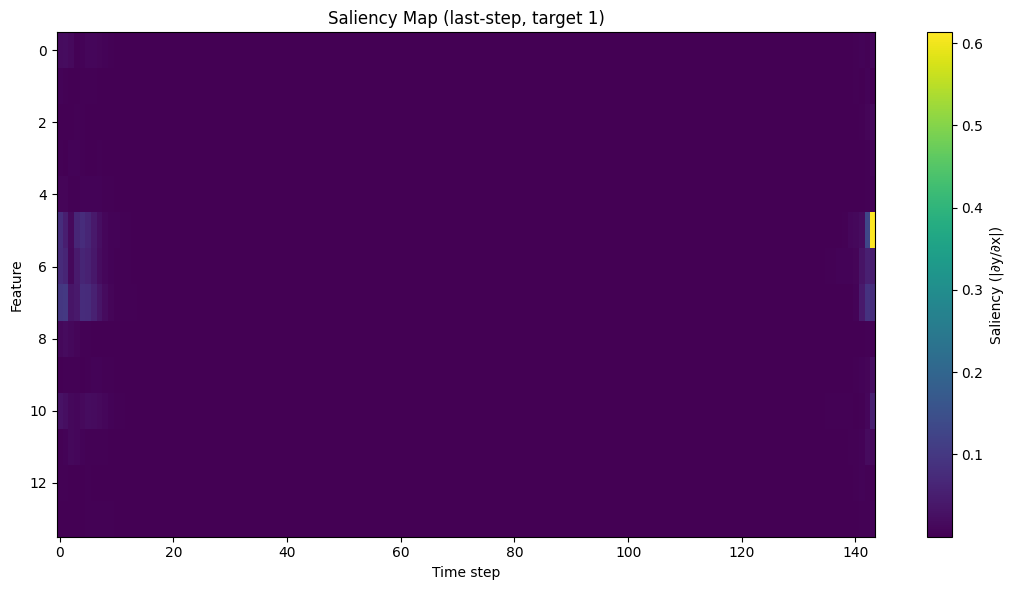

In [24]:
# -----------------------------
# ✅ Step 6: Residual Analysis + Saliency Maps (corrected)
# -----------------------------
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---------- 0) Choose evaluation scale ----------
# Use the scaled validation loader so y and preds are on the same scale
use_scaled = True  # set False to compute residuals in original units

# ---------- 1) Collect predictions & targets consistently ----------
all_preds, all_targets = [], []
model.eval()

if use_scaled:
    # Scaled space: val_loader_s yields scaled targets
    with torch.no_grad():
        for xb, y_scaled in val_loader_s:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()             # (B, H, D) or (B, H)
            all_preds.append(preds)
            all_targets.append(y_scaled.cpu().numpy())  # (B, H, D) or (B, H)
else:
    # Original space: inverse-transform predictions only, compare to raw y
    with torch.no_grad():
        for xb, y_raw in val_loader:                    # raw targets
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()             # scaled preds
            if preds.ndim == 3:
                B, H, D = preds.shape
                preds_2d = preds.reshape(-1, D)
                preds_inv = y_scaler.inverse_transform(preds_2d).reshape(B, H, D)
            else:
                B, H = preds.shape
                preds_2d = preds.reshape(-1, 1)
                preds_inv = y_scaler.inverse_transform(preds_2d).reshape(B, H)
            all_preds.append(preds_inv)
            all_targets.append(y_raw.cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0)           # (B, H, D) or (B, H) or (B,)
all_targets = np.concatenate(all_targets, axis=0)

# Harmonize shapes and build 2D matrices (N, D) for per-target analysis
if all_preds.ndim == 3:
    B, H, D = all_preds.shape
    pred_2d = all_preds.reshape(-1, D)                  # (B*H, D)
    true_2d = all_targets.reshape(-1, D)                # (B*H, D)
    n_targets = D
elif all_preds.ndim == 2:
    B, H = all_preds.shape
    pred_2d = all_preds.reshape(-1, 1)                  # (B*H, 1)
    true_2d = all_targets.reshape(-1, 1)                # (B*H, 1)
    n_targets = 1
else:  # (N,)
    pred_2d = all_preds.reshape(-1, 1)
    true_2d = all_targets.reshape(-1, 1)
    n_targets = 1

resid_2d = true_2d - pred_2d                            # (N, D)

# Also prepare flattened arrays for global diagnostics
y_pred_flat = pred_2d.reshape(-1)
residuals_flat = resid_2d.reshape(-1)

# ---------- 2) Global residual diagnostics ----------
plt.figure(figsize=(8, 4))
plt.hist(residuals_flat, bins=40, alpha=0.8, color='steelblue', edgecolor='white')
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(y_pred_flat, residuals_flat, s=6, alpha=0.4, color='tab:blue')
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# ---------- 3) Per-target residual histograms ----------
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 4))
axes = np.atleast_1d(axes)
for i in range(n_targets):
    axes[i].hist(resid_2d[:, i], bins=30, alpha=0.75, color='skyblue', edgecolor='white')
    axes[i].set_title(f"Residuals - Target {i+1}")
    axes[i].set_xlabel("Residual")
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# ---------- 4) Saliency maps (gradient-based) ----------
# Use scaled inputs to match how the model was trained/evaluated
xb, yb = next(iter(val_loader_s))
xb = xb.to(device).detach().requires_grad_(True)

# Predict and select a scalar output to explain (last horizon step, target 0)
preds_batch = model(xb)                                  # (B, H, D) or (B, H)
if preds_batch.ndim == 3:
    loss = preds_batch[:, -1, 0].sum()
elif preds_batch.ndim == 2:
    loss = preds_batch[:, -1].sum()
else:
    loss = preds_batch.sum()

model.zero_grad(set_to_none=True)
if xb.grad is not None:
    xb.grad.zero_()
loss.backward()

# Saliency = mean absolute input gradient over the batch -> (T, F)
saliency = xb.grad.abs().mean(dim=0).detach().cpu().numpy()  # assume inputs shaped (B, T, F)

# Plot saliency heatmap (Features × Time)
plt.figure(figsize=(11, 6))
plt.imshow(saliency.T, cmap="viridis", aspect="auto")
plt.colorbar(label="Saliency (|∂y/∂x|)")
plt.xlabel("Time step")
plt.ylabel("Feature")
plt.title("Saliency Map (last-step, target 1)")
plt.tight_layout()
plt.show()

### Step 6: Residual & Error Analysis  

- Computed **residuals** for the top model on validation data.  
- Plotted **residual histogram** to check error spread.  
- Plotted **residuals vs predictions** to identify bias patterns.  

In [25]:
# 🔍 Check what columns are available in final_df
print("final_df columns:", list(final_df.columns))
print(final_df.head(3))


final_df columns: ['config', 'model', 'rmse', 'mae', 'r2', 'orig_rmse', 'orig_mae', 'orig_r2', 'ckpt']
      config      model      rmse       mae        r2    orig_rmse  \
0  lb144_hr6   GRUModel  0.099311  0.067155  0.989075   612.064029   
1  lb144_hr6  LSTMModel  0.101362  0.072371  0.988620   630.342838   
2  lb144_hr6   TCNModel  0.299721  0.232929  0.900497  1811.951089   

      orig_mae   orig_r2                                               ckpt  
0   416.903412  0.980309  C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...  
1   450.134521  0.980273  C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...  
2  1433.999023  0.828062  C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powe...  


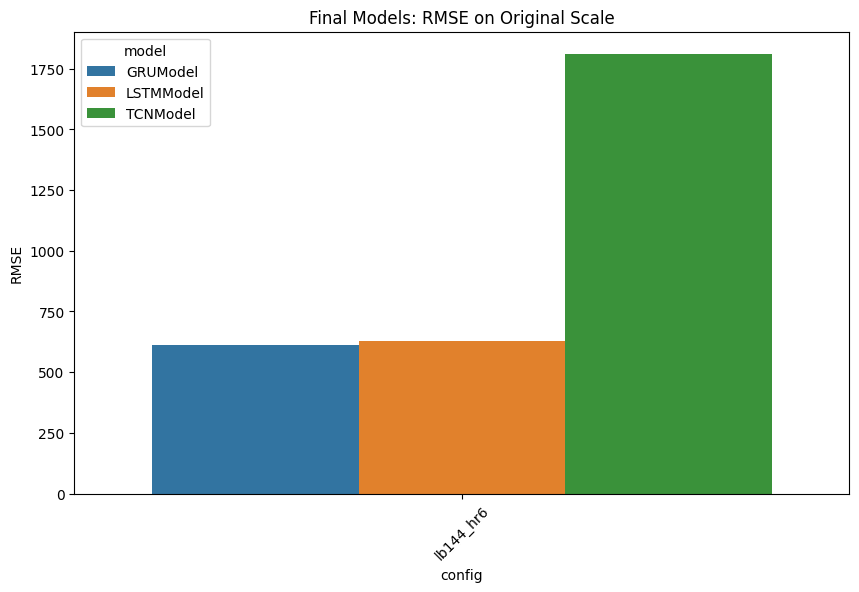

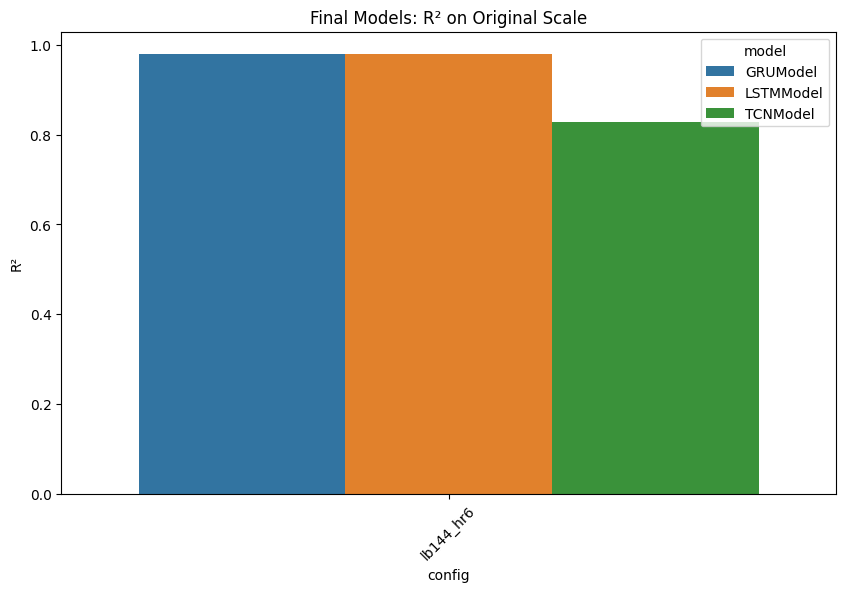

In [26]:
# -----------------------------
# ✅ Step 7: Results Export + Visualization
# -----------------------------
import seaborn as sns

# save final leaderboard to CSV
final_csv_path = os.path.join(assets_dir, "leaderboard", "final_results.csv")
os.makedirs(os.path.dirname(final_csv_path), exist_ok=True)
final_df.to_csv(final_csv_path, index=False)

# log leaderboard to MLflow
with mlflow.start_run(run_name="Final_Leaderboard"):
    mlflow.log_artifact(final_csv_path)

# visualize RMSE across configs
plt.figure(figsize=(10, 6))
sns.barplot(data=final_df, x="config", y="orig_rmse", hue="model")
plt.title("Final Models: RMSE on Original Scale")
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.show()

# visualize R² scores
plt.figure(figsize=(10, 6))
sns.barplot(data=final_df, x="config", y="orig_r2", hue="model")
plt.title("Final Models: R² on Original Scale")
plt.xticks(rotation=45)
plt.ylabel("R²")
plt.show()

### Step 7: Results Export + Visualization  

- Exported the **final leaderboard** to CSV and logged it in **MLflow**.  
- Plotted **RMSE** across configs and models for comparison.  
- Plotted **R² scores** to visualize performance robustness.  

In [27]:
# -----------------------------
# ✅ Step 8: Save Best Checkpoints (safer version)
# -----------------------------
import shutil

best_ckpt_dir = os.path.join(assets_dir, "best_checkpoints")
os.makedirs(best_ckpt_dir, exist_ok=True)

saved_ckpts = []

# For each (config, model), pick the row with lowest orig_rmse
best_rows = (
    final_df.groupby(["config", "model"])
    .apply(lambda g: g.sort_values("orig_rmse").iloc[0])
    .reset_index(drop=True)
)

for _, row in best_rows.iterrows():
    src = row["ckpt"]
    # unique name: config_model.pt (avoids accidental overwrites)
    dst_name = f"{row['config']}_{row['model']}.pt"
    dst = os.path.join(best_ckpt_dir, dst_name)

    # copy checkpoint if not already present
    if not os.path.exists(dst):
        shutil.copy(src, dst)
    saved_ckpts.append(dst)

print(f"✅ Saved {len(saved_ckpts)} best checkpoints for deployment:")
for ckpt in saved_ckpts:
    print(" -", ckpt)

✅ Saved 3 best checkpoints for deployment:
 - C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\best_checkpoints\lb144_hr6_GRUModel.pt
 - C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\best_checkpoints\lb144_hr6_LSTMModel.pt
 - C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\best_checkpoints\lb144_hr6_TCNModel.pt


C:\Users\ABCD\AppData\Local\Temp\ipykernel_7296\1520869387.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("orig_rmse").iloc[0])


### Step 8: Save Best Checkpoints  

- Picked the **top model per config + family** (lowest RMSE).  
- Saved checkpoints into `assets/best_checkpoints/`.  
- Ensured they are ready for **Week 5 deployment**.  

In [29]:
# -----------------------------
# ✅ Step 9: Export Final Report (polished, with Markdown fallback)
# -----------------------------
import os, io
import pandas as pd
import mlflow

report_path = os.path.join(assets_dir, "leaderboard", "final_report.md")
os.makedirs(os.path.dirname(report_path), exist_ok=True)

def df_to_markdown_fallback(df: pd.DataFrame, index=False):
    """Minimal Markdown table formatter (no external deps)."""
    cols = list(df.columns)
    rows = df.values.tolist()
    # Header
    out = []
    out.append("| " + " | ".join(cols) + " |")
    out.append("| " + " | ".join(["---"] * len(cols)) + " |")
    # Rows
    for r in rows:
        out.append("| " + " | ".join(map(str, r)) + " |")
    return "\n".join(out)

top_models = final_df.sort_values("orig_rmse").head(5)

# Try native to_markdown first
try:
    top_md = top_models.to_markdown(index=False)  # requires 'tabulate' [web:343][web:349]
except Exception:
    top_md = df_to_markdown_fallback(top_models, index=False)  # no-deps fallback

with open(report_path, "w", encoding="utf-8") as f:
    f.write("# Phase 3 Model Tuning Report\n\n")

    # Summary section
    f.write("## Summary\n")
    f.write(f"- Total configs evaluated: {len(results)}\n")
    f.write(f"- Final leaderboard size: {final_df.shape[0]} models\n\n")

    # Top models section
    f.write("## Top Models (by RMSE)\n")
    f.write(top_md + "\n\n")

    # Notes section
    f.write("## Notes\n")
    f.write("- Results are based on **scaled training** with Week 3 scalers.\n")
    f.write("- Metrics reported on **original target scale** for interpretability.\n")
    f.write("- Best checkpoints are saved in `assets/best_checkpoints/`.\n")

# Log report to MLflow (separate run for clarity)
with mlflow.start_run(run_name="Final_Report"):
    mlflow.log_artifact(report_path)  # logs file artifact into the run [web:160]

print(f"✅ Final report exported and logged to MLflow: {report_path}")

✅ Final report exported and logged to MLflow: C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\leaderboard\final_report.md


### Step 9: Export Final Report  

- Compiled a **Phase 3 tuning report** with summary, top models, and notes.  
- Exported the report as `final_report.md` inside the leaderboard folder.  
- Logged the report as an **artifact in MLflow** for experiment tracking.  